(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

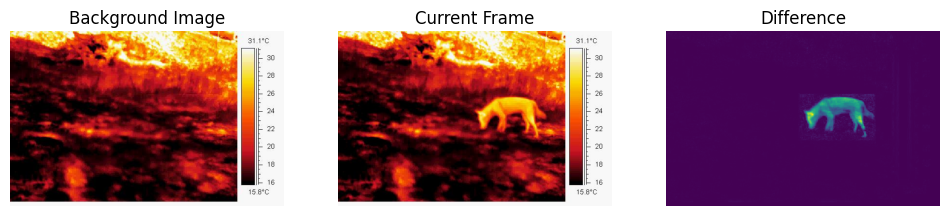

In [37]:
# CVIA Lab Week 4 - Code Example 1: Background Subtraction (Image Segmentation)
# Author: Min Wang
# Created: 2026/02/26

# Import libraries
import cv2
import numpy as np
import os 
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load images
# ---------------------------
input_img = cv2.imread("DINGO3_Frame0.jpg")
background_img = cv2.imread("DINGO3_Background.jpg")

input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
background_img = cv2.cvtColor(background_img, cv2.COLOR_BGR2RGB)
# ---------------------------
# Step 2: Convert to Grayscale
# ---------------------------
gray_input = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
gray_background = cv2.cvtColor(background_img, cv2.COLOR_BGR2GRAY)

# ---------------------------
# Step 3: Compute Difference Image
# ---------------------------
diff_img = cv2.absdiff(gray_input, gray_background)

# plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(background_img)
plt.title("Background Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(input_img)
plt.title("Current Frame")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(diff_img)
plt.title("Difference")
plt.axis('off')

(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

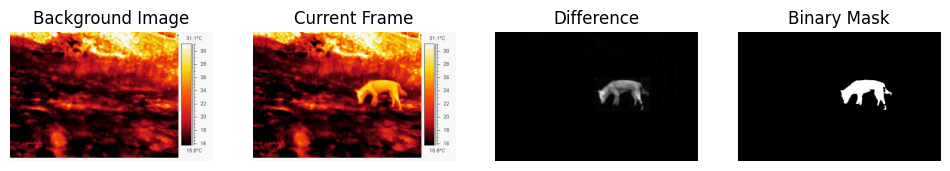

In [38]:
# ---------------------------
# Step 4: Thresholding
# ---------------------------

# This converts a grayscale image into a binary image. Try different threshold values
threshold_value = 40
_, binary_mask = cv2.threshold(
    diff_img,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

# plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(background_img)
plt.title("Background Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(input_img)
plt.title("Current Frame")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(diff_img, cmap='gray')
plt.title("Difference")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask")
plt.axis('off')

(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

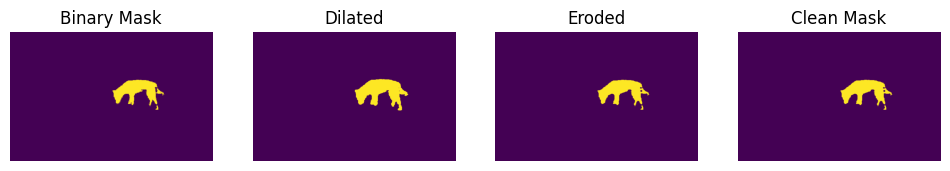

In [39]:
# ---------------------------
# Step 5: Morphological Operations (new)
# ---------------------------

# Create the structuring element, try different kernel sizes
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

# Perform dilation, then observe how foreground regions grow:
dilated = cv2.dilate(binary_mask, kernel)

# Perform erosion, then observe how noise is removed:
eroded = cv2.erode(dilated, kernel)

# Apply dilation and erosion together
clean_mask = cv2.morphologyEx(
    binary_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(binary_mask)
plt.title("Binary Mask")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(dilated)
plt.title("Dilated")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(eroded)
plt.title("Eroded")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(clean_mask)
plt.title("Clean Mask")
plt.axis('off')

(np.float64(-0.5), np.float64(563.5), np.float64(359.5), np.float64(-0.5))

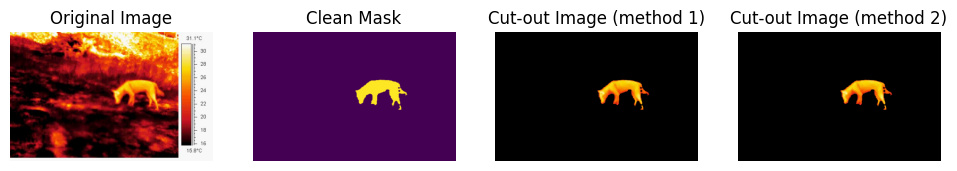

In [40]:
# ---------------------------
# Step 6: Applying the Binary Mask
# ---------------------------

# Method 1 — Elementwise Multiplication (Recommended)
mask_3ch = cv2.cvtColor(clean_mask, cv2.COLOR_GRAY2BGR) / 255.0
cut_out_img = (input_img * mask_3ch).astype(np.uint8)

# Method 2 — Using Loops (not recommended, why? ---- slow, inefficient)
result = input_img.copy()

for y in range(clean_mask.shape[0]):
    for x in range(clean_mask.shape[1]):
        if clean_mask[y, x] == 0:
            result[y, x] = 0

# plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(input_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(clean_mask)
plt.title("Clean Mask")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(cut_out_img)
plt.title("Cut-out Image (method 1)")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(result)
plt.title("Cut-out Image (method 2)")
plt.axis('off')